# 00 - Setup & Data Validation

**StormVision**: Small-object detection in maritime drone imagery with synthetic stormy sea data generation.

This notebook:
1. Installs all required dependencies
2. Detects GPU and prints CUDA details
3. Defines project paths and verifies data structure
4. Scans dataset and auto-detects annotation format
5. Validates image-label matching
6. Shows sample images with bboxes

## Configuration

In [10]:
# ============================================================
# CONFIGURATION - Edit these values as needed
# ============================================================

SEED = 42
IMG_SIZE = 640
BATCH_SIZE = 16
MODEL = 'yolov8l.pt'
EPOCHS = 50
DEVICE = 'cuda'  # Will be validated below

# Number of sample images to display
N_SAMPLES = 5

## 1. Install Dependencies

In [11]:
%%capture
# Core ML & CV dependencies
!pip install -q ultralytics torch torchvision opencv-python pillow matplotlib pandas tqdm scikit-learn

# COCO tools for annotation parsing
!pip install -q pycocotools

# Diffusion stack for synthetic generation
!pip install -q diffusers transformers accelerate safetensors

# Segment Anything Model (SAM)
!pip install -q segment-anything

# Optional: xformers for memory-efficient attention (may fail on some systems)
!pip install -q xformers 2>/dev/null || echo 'xformers not available, will use standard attention'

print('[OK] All dependencies installed!')

## 2. GPU Detection

In [12]:
import torch
import os
import random
import numpy as np

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('=' * 60)
print('GPU / CUDA INFORMATION')
print('=' * 60)

if torch.cuda.is_available():
    DEVICE = 'cuda'
    print(f'[OK] CUDA is available!')
    print(f'   PyTorch version: {torch.__version__}')
    print(f'   CUDA version: {torch.version.cuda}')
    print(f'   cuDNN version: {torch.backends.cudnn.version()}')
    print(f'   Number of GPUs: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'   GPU {i}: {props.name}')
        print(f'      - Memory: {props.total_memory / 1e9:.2f} GB')
        print(f'      - Compute Capability: {props.major}.{props.minor}')
else:
    DEVICE = 'cpu'
    print('[WARNING] CUDA not available, using CPU')
    print('   Note: Training will be significantly slower')

print(f'\n Using device: {DEVICE}')

GPU / CUDA INFORMATION
[WARNING] CUDA not available, using CPU
   Note: Training will be significantly slower

 Using device: cpu


## 3. Project Paths Setup

In [13]:
from pathlib import Path
import json
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Project root - hardcoded for Colab with Drive
PROJECT_ROOT = Path('/content/drive/MyDrive/StormVision')

# Define all paths
PATHS = {
    'data': PROJECT_ROOT / 'data',
    'train_images': PROJECT_ROOT / 'data' / 'train',
    'val_images': PROJECT_ROOT / 'data' / 'val',
    'annotations': PROJECT_ROOT / 'data' / 'annotations',
    'processed': PROJECT_ROOT / 'data' / 'processed',
    'synthetic': PROJECT_ROOT / 'data' / 'synthetic',
    'splits': PROJECT_ROOT / 'data' / 'splits',
    'results': PROJECT_ROOT / 'results',
    'figures': PROJECT_ROOT / 'results' / 'figures',
    'metrics': PROJECT_ROOT / 'results' / 'metrics',
    'predictions': PROJECT_ROOT / 'results' / 'predictions',
}

# Create output directories
for name in ['processed', 'synthetic', 'splits', 'results', 'figures', 'metrics', 'predictions']:
    PATHS[name].mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print('\nDirectory Structure:')
for name, path in PATHS.items():
    exists = '[OK]' if path.exists() else '[MISSING]'
    print(f'   {exists} {name}: {path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/StormVision

Directory Structure:
   [OK] data: /content/drive/MyDrive/StormVision/data
   [OK] train_images: /content/drive/MyDrive/StormVision/data/train
   [OK] val_images: /content/drive/MyDrive/StormVision/data/val
   [OK] annotations: /content/drive/MyDrive/StormVision/data/annotations
   [OK] processed: /content/drive/MyDrive/StormVision/data/processed
   [OK] synthetic: /content/drive/MyDrive/StormVision/data/synthetic
   [OK] splits: /content/drive/MyDrive/StormVision/data/splits
   [OK] results: /content/drive/MyDrive/StormVision/results
   [OK] figures: /content/drive/MyDrive/StormVision/results/figures
   [OK] metrics: /content/drive/MyDrive/StormVision/results/metrics
   [OK] predictions: /content/drive/MyDrive/StormVision/results/predictions


## 4. Data Structure Scan

In [14]:
import glob

def count_files(directory, extensions=('*.jpg', '*.jpeg', '*.png')):
    """Count image files in a directory."""
    count = 0
    if directory.exists():
        for ext in extensions:
            count += len(list(directory.glob(ext)))
    return count

def get_folder_tree(path, prefix='', max_depth=2, current_depth=0):
    """Print folder tree structure."""
    if current_depth >= max_depth:
        return

    if path.is_dir():
        items = sorted(path.iterdir())
        dirs = [item for item in items if item.is_dir() and not item.name.startswith('.')]
        files = [item for item in items if item.is_file() and not item.name.startswith('.')]

        # Count files per type
        file_counts = {}
        for f in files:
            ext = f.suffix.lower()
            file_counts[ext] = file_counts.get(ext, 0) + 1

        file_summary = ', '.join([f'{count} {ext}' for ext, count in file_counts.items()])
        if file_summary:
            print(f'{prefix}[DIR] {path.name}/ ({file_summary})')
        else:
            print(f'{prefix}[DIR] {path.name}/')

        for d in dirs:
            get_folder_tree(d, prefix + '   ', max_depth, current_depth + 1)

print('=' * 60)
print('DATA STRUCTURE SCAN')
print('=' * 60)

if PATHS['data'].exists():
    get_folder_tree(PATHS['data'], max_depth=3)

    print('\n Image Counts:')
    train_count = count_files(PATHS['train_images'])
    val_count = count_files(PATHS['val_images'])
    print(f'   Train images: {train_count:,}')
    print(f'   Val images:   {val_count:,}')
    print(f'   Total:        {train_count + val_count:,}')
else:
    print('[ERROR] Data directory not found!')
    print(f'   Expected at: {PATHS["data"]}')

DATA STRUCTURE SCAN
[DIR] data/
   [DIR] annotations/ (2 .json)
   [DIR] processed/
   [DIR] splits/
   [DIR] synthetic/
   [DIR] train/ (8930 .jpg)
   [DIR] val/ (1547 .jpg)

 Image Counts:
   Train images: 8,930
   Val images:   1,547
   Total:        10,477


## 5. Annotation Format Detection

In [15]:
def detect_annotation_format(data_path):
    """
    Auto-detect annotation format.
    Returns: 'coco', 'yolo', 'voc', or None
    """
    annotations_dir = data_path / 'annotations'
    labels_dir = data_path / 'labels'

    # Check for COCO JSON
    if annotations_dir.exists():
        json_files = list(annotations_dir.glob('*.json'))
        for jf in json_files:
            try:
                with open(jf) as f:
                    data = json.load(f)
                if 'annotations' in data and 'images' in data and 'categories' in data:
                    return 'coco', json_files
            except:
                pass

    # Check for YOLO txt files
    if labels_dir.exists():
        txt_files = list(labels_dir.glob('**/*.txt'))
        if txt_files:
            return 'yolo', txt_files

    # Check for VOC XML
    xml_files = list(data_path.glob('**/*.xml'))
    if xml_files:
        return 'voc', xml_files

    return None, []

print('=' * 60)
print('ANNOTATION FORMAT DETECTION')
print('=' * 60)

ann_format, ann_files = detect_annotation_format(PATHS['data'])

if ann_format == 'coco':
    print(f'[OK] Detected: COCO JSON format')
    print(f'   Found {len(ann_files)} annotation file(s):')
    for f in ann_files:
        print(f'   - {f.name}')

    # Load and analyze COCO annotations
    COCO_DATA = {}
    for split in ['train', 'val']:
        ann_path = PATHS['annotations'] / f'instances_{split}.json'
        if ann_path.exists():
            with open(ann_path) as f:
                COCO_DATA[split] = json.load(f)
            print(f'\n    {split} annotations:')
            print(f'      Images: {len(COCO_DATA[split]["images"]):,}')
            print(f'      Annotations: {len(COCO_DATA[split]["annotations"]):,}')

    # Show categories
    if 'train' in COCO_DATA:
        print('\n    Categories:')
        for cat in COCO_DATA['train']['categories']:
            print(f'      {cat["id"]}: {cat["name"]} (supercategory: {cat.get("supercategory", "N/A")})')

elif ann_format == 'yolo':
    print(f'[OK] Detected: YOLO txt format')
    print(f'   Found {len(ann_files)} label file(s)')

elif ann_format == 'voc':
    print(f'[OK] Detected: VOC XML format')
    print(f'   Found {len(ann_files)} annotation file(s)')

else:
    print('[WARNING] Could not detect annotation format')
    print('   Please ensure annotations are in ./data/annotations/ (COCO JSON)')
    print('   or ./data/labels/ (YOLO txt)')

ANNOTATION FORMAT DETECTION
[OK] Detected: COCO JSON format
   Found 2 annotation file(s):
   - instances_val.json
   - instances_train.json

    train annotations:
      Images: 8,930
      Annotations: 57,760

    val annotations:
      Images: 1,547
      Annotations: 9,630

    Categories:
      0: ignored (supercategory: ignored)
      1: swimmer (supercategory: person)
      2: boat (supercategory: boat)
      3: jetski (supercategory: boat)
      4: life_saving_appliances (supercategory: object)
      5: buoy (supercategory: object)


## 6. Image-Annotation Matching Validation

In [16]:
from collections import Counter

def validate_coco_matching(coco_data, images_dir, split_name):
    """
    Validate that all annotated images exist and check for issues.
    """
    issues = []
    stats = {
        'total_images': len(coco_data['images']),
        'total_annotations': len(coco_data['annotations']),
        'images_found': 0,
        'images_missing': 0,
        'empty_labels': 0,
        'invalid_bbox': 0,
    }

    # Build image_id to filename mapping
    id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}

    # Check if images exist
    for img in coco_data['images']:
        img_path = images_dir / img['file_name']
        if img_path.exists():
            stats['images_found'] += 1
        else:
            stats['images_missing'] += 1
            if stats['images_missing'] <= 5:
                issues.append(f"Missing image: {img['file_name']}")

    # Count annotations per image
    ann_per_image = Counter(ann['image_id'] for ann in coco_data['annotations'])

    # Find images with no annotations
    for img in coco_data['images']:
        if img['id'] not in ann_per_image:
            stats['empty_labels'] += 1

    # Check for invalid bboxes
    id_to_dims = {img['id']: (img['width'], img['height']) for img in coco_data['images']}
    for ann in coco_data['annotations']:
        bbox = ann['bbox']  # [x, y, width, height] in COCO format
        img_w, img_h = id_to_dims.get(ann['image_id'], (0, 0))

        # Check bounds
        if bbox[0] < 0 or bbox[1] < 0 or bbox[2] <= 0 or bbox[3] <= 0:
            stats['invalid_bbox'] += 1
        elif bbox[0] + bbox[2] > img_w or bbox[1] + bbox[3] > img_h:
            stats['invalid_bbox'] += 1

    return stats, issues

print('=' * 60)
print('IMAGE-ANNOTATION MATCHING VALIDATION')
print('=' * 60)

if ann_format == 'coco' and 'train' in COCO_DATA:
    for split in ['train', 'val']:
        if split in COCO_DATA:
            images_dir = PATHS[f'{split}_images']
            stats, issues = validate_coco_matching(COCO_DATA[split], images_dir, split)

            print(f'\n {split.upper()} Split:')
            print(f'   Total images in annotations: {stats["total_images"]:,}')
            print(f'   Images found on disk: {stats["images_found"]:,}')
            print(f'   Images missing: {stats["images_missing"]:,}')
            print(f'   Images with no annotations: {stats["empty_labels"]:,}')
            print(f'   Invalid bbox coordinates: {stats["invalid_bbox"]:,}')

            if stats['images_missing'] == 0 and stats['invalid_bbox'] == 0:
                print(f'   [OK] All validations passed!')
            else:
                print(f'   [WARNING] Issues detected')
                for issue in issues[:5]:
                    print(f'      - {issue}')
else:
    print('[WARNING] Skipping validation - COCO data not loaded')

IMAGE-ANNOTATION MATCHING VALIDATION

 TRAIN Split:
   Total images in annotations: 8,930
   Images found on disk: 8,930
   Images missing: 0
   Images with no annotations: 0
   Invalid bbox coordinates: 0
   [OK] All validations passed!

 VAL Split:
   Total images in annotations: 1,547
   Images found on disk: 1,547
   Images missing: 0
   Images with no annotations: 0
   Invalid bbox coordinates: 0
   [OK] All validations passed!


## 7. Sample Visualization

SAMPLE VISUALIZATION (5 random images)


/tmp/ipython-input-1942725714.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


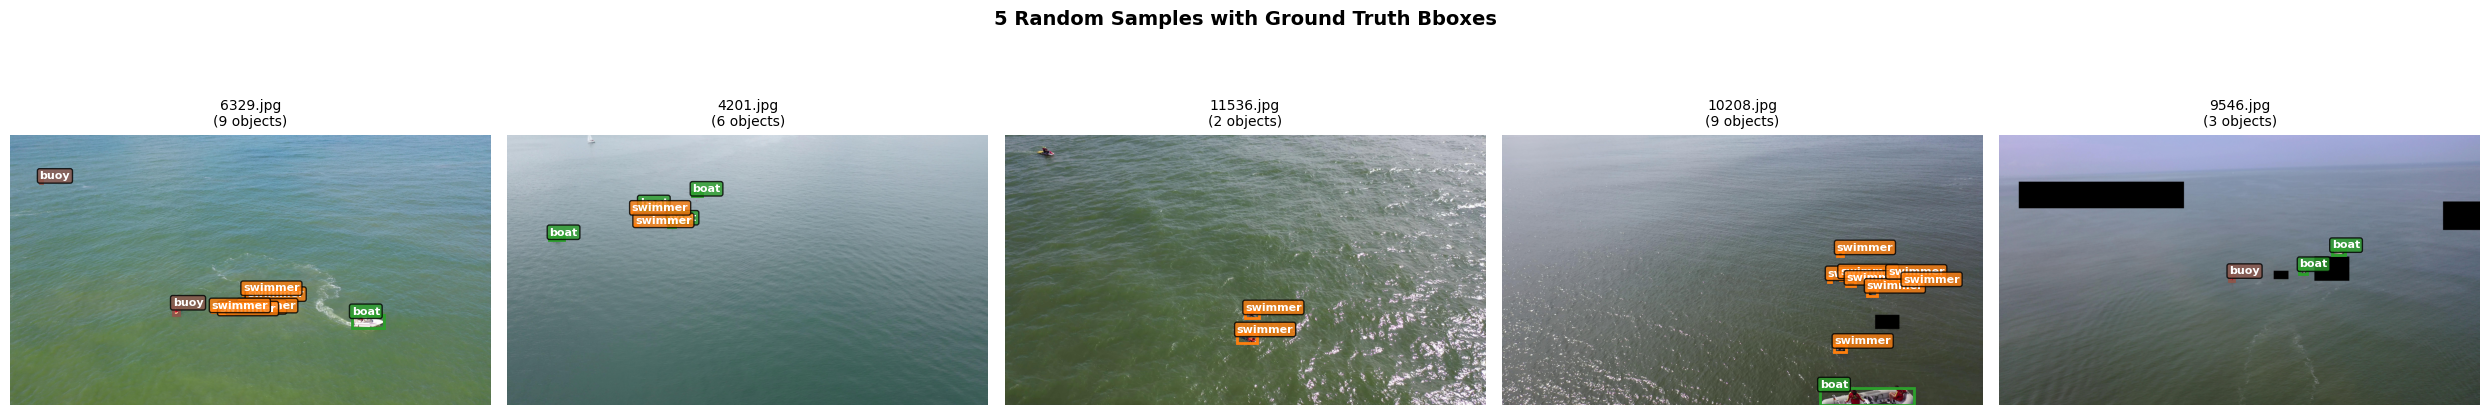


 Category Legend:
   0: ignored
   1: swimmer
   2: boat
   3: jetski
   4: life_saving_appliances
   5: buoy


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

def get_category_colors(categories):
    """Generate distinct colors for each category."""
    cmap = plt.cm.get_cmap('tab10')
    colors = {}
    for i, cat in enumerate(categories):
        colors[cat['id']] = cmap(i % 10)
    return colors

def draw_bboxes(ax, annotations, category_colors, category_names):
    """Draw bounding boxes on an axis."""
    for ann in annotations:
        bbox = ann['bbox']  # [x, y, width, height]
        cat_id = ann['category_id']
        color = category_colors.get(cat_id, 'red')
        cat_name = category_names.get(cat_id, str(cat_id))

        rect = patches.Rectangle(
            (bbox[0], bbox[1]), bbox[2], bbox[3],
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            bbox[0], bbox[1] - 5, cat_name,
            color='white', fontsize=8, weight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8)
        )

def visualize_samples(coco_data, images_dir, n_samples=5, seed=42):
    """Visualize random samples with bounding boxes."""
    random.seed(seed)

    # Get category info
    categories = coco_data['categories']
    category_colors = get_category_colors(categories)
    category_names = {cat['id']: cat['name'] for cat in categories}

    # Build image_id to annotations mapping
    img_to_anns = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in img_to_anns:
            img_to_anns[img_id] = []
        img_to_anns[img_id].append(ann)

    # Filter images that have annotations
    valid_images = [img for img in coco_data['images'] if img['id'] in img_to_anns]
    samples = random.sample(valid_images, min(n_samples, len(valid_images)))

    # Create visualization
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    for ax, img_info in zip(axes, samples):
        img_path = images_dir / img_info['file_name']
        if img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img)

            # Draw bboxes
            anns = img_to_anns.get(img_info['id'], [])
            draw_bboxes(ax, anns, category_colors, category_names)

            ax.set_title(f"{img_info['file_name']}\n({len(anns)} objects)", fontsize=10)
        else:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
            ax.set_title(img_info['file_name'])

        ax.axis('off')

    plt.tight_layout()
    plt.suptitle(f'{len(samples)} Random Samples with Ground Truth Bboxes', y=1.02, fontsize=14, weight='bold')
    plt.show()

    # Show legend
    print('\n Category Legend:')
    for cat in categories:
        print(f'   {cat["id"]}: {cat["name"]}')

print('=' * 60)
print(f'SAMPLE VISUALIZATION ({N_SAMPLES} random images)')
print('=' * 60)

if ann_format == 'coco' and 'train' in COCO_DATA:
    visualize_samples(COCO_DATA['train'], PATHS['train_images'], n_samples=N_SAMPLES, seed=SEED)
else:
    print('[WARNING] Cannot visualize - COCO data not loaded')

## 8. Summary & Export Config

In [18]:
# Export configuration for other notebooks
CONFIG = {
    'SEED': SEED,
    'PROJECT_ROOT': str(PROJECT_ROOT),
    'IMG_SIZE': IMG_SIZE,
    'BATCH_SIZE': BATCH_SIZE,
    'MODEL': MODEL,
    'EPOCHS': EPOCHS,
    'DEVICE': DEVICE,
    'ANNOTATION_FORMAT': ann_format,
    'CATEGORIES': COCO_DATA['train']['categories'] if ann_format == 'coco' and 'train' in COCO_DATA else [],
    'TRAIN_IMAGES': len(COCO_DATA['train']['images']) if 'train' in COCO_DATA else 0,
    'VAL_IMAGES': len(COCO_DATA['val']['images']) if 'val' in COCO_DATA else 0,
}

# Save config
config_path = PATHS['processed'] / 'config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)

print('=' * 60)
print('SETUP SUMMARY')
print('=' * 60)
print(f'\n[OK] Setup complete!')
print(f'\n Configuration:')
for key, value in CONFIG.items():
    if key != 'CATEGORIES':
        print(f'   {key}: {value}')
print(f'\n Config saved to: {config_path}')
print(f'\n Ready to proceed with:')
print(f'   1. 01_eda.ipynb - Exploratory Data Analysis')
print(f'   2. 02_synthetic_generation.ipynb - Storm Background Generation')
print(f'   3. 03_train_eval_compare.ipynb - Model Training & Evaluation')

SETUP SUMMARY

[OK] Setup complete!

 Configuration:
   SEED: 42
   PROJECT_ROOT: /content/drive/MyDrive/StormVision
   IMG_SIZE: 640
   BATCH_SIZE: 16
   MODEL: yolov8l.pt
   EPOCHS: 50
   DEVICE: cpu
   ANNOTATION_FORMAT: coco
   TRAIN_IMAGES: 8930
   VAL_IMAGES: 1547

 Config saved to: /content/drive/MyDrive/StormVision/data/processed/config.json

 Ready to proceed with:
   1. 01_eda.ipynb - Exploratory Data Analysis
   2. 02_synthetic_generation.ipynb - Storm Background Generation
   3. 03_train_eval_compare.ipynb - Model Training & Evaluation
